In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("StressLevelDataset.csv")

df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [3]:
df.shape

(1100, 21)

In [4]:
df["academic_performance"].unique()

array([3, 1, 2, 4, 5, 0])

In [5]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [6]:
df.isnull().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

In [7]:
df.duplicated().sum().sum()

np.int64(0)

In [8]:
df["stress_level"].value_counts()

stress_level
0    373
2    369
1    358
Name: count, dtype: int64

## EDA

In [ ]:
print(df.corr()['stress_level'].abs().sort_values(ascending=False))
## checking how the other columns are correkated to stress level column

stress_level                    1.000000
self_esteem                     0.756195
bullying                        0.751162
sleep_quality                   0.749068
future_career_concerns          0.742619
anxiety_level                   0.736795
depression                      0.734379
academic_performance            0.720922
headache                        0.713484
safety                          0.709602
basic_needs                     0.708968
extracurricular_activities      0.692977
peer_pressure                   0.690684
teacher_student_relationship    0.680163
noise_level                     0.663371
mental_health_history           0.648644
study_load                      0.634156
social_support                  0.632497
living_conditions               0.581723
breathing_problem               0.573984
blood_pressure                  0.394200
Name: stress_level, dtype: float64


In [10]:
pd.crosstab(df["mental_health_history"], df["stress_level"])

stress_level,0,1,2
mental_health_history,,,
0,335,183,40
1,38,175,329


In [11]:
pd.crosstab(df["blood_pressure"], df["stress_level"])

stress_level,0,1,2
blood_pressure,,,
1,0,300,0
2,300,0,0
3,73,58,369


In [12]:
pd.crosstab(df["living_conditions"], df["stress_level"])

stress_level,0,1,2
living_conditions,,,
0,12,8,9
1,15,9,152
2,9,163,174
3,155,161,11
4,172,7,10
5,10,10,13


Text(0.5, 1.0, 'Stress level distribution')

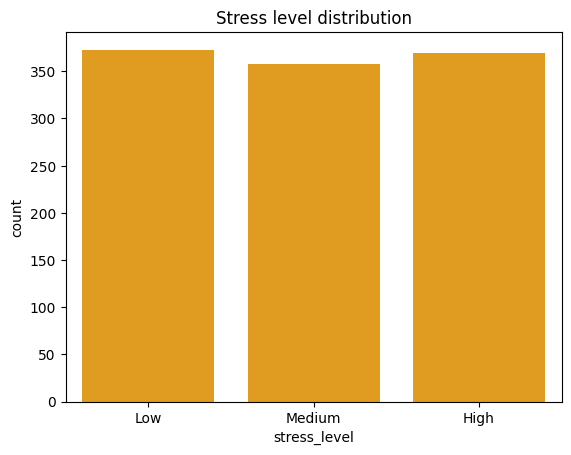

In [13]:
sns.countplot(data=df, x="stress_level", color="orange")
plt.xticks([0,1,2], ["Low", "Medium", "High"])
plt.title("Stress level distribution")
## somewhat of balanced values

<Axes: xlabel='mental_health_history', ylabel='stress_level'>

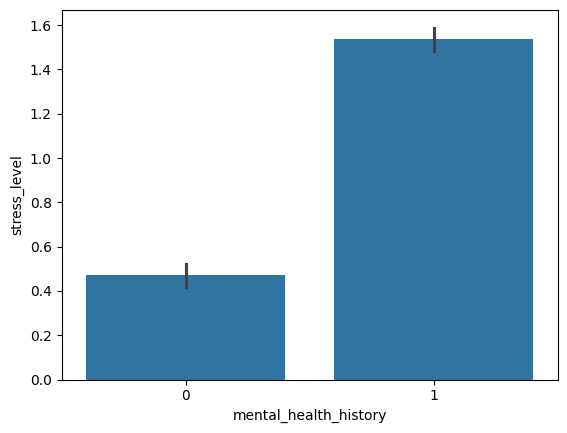

In [14]:
sns.barplot(data=df, x="mental_health_history", y="stress_level")

## this tells that mental_health_history result in more stress

(array([121., 121., 147., 177., 174., 143., 217.]),
 array([ 0.,  3.,  6.,  9., 12., 15., 18., 21.]),
 <BarContainer object of 7 artists>)

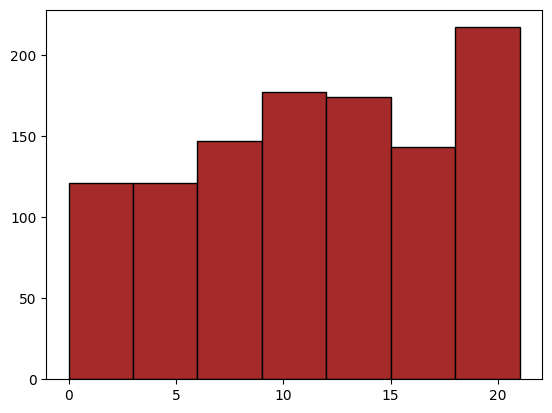

In [15]:
plt.hist(df["anxiety_level"], bins=7, edgecolor="black", color="brown")
## anxiety level distribution

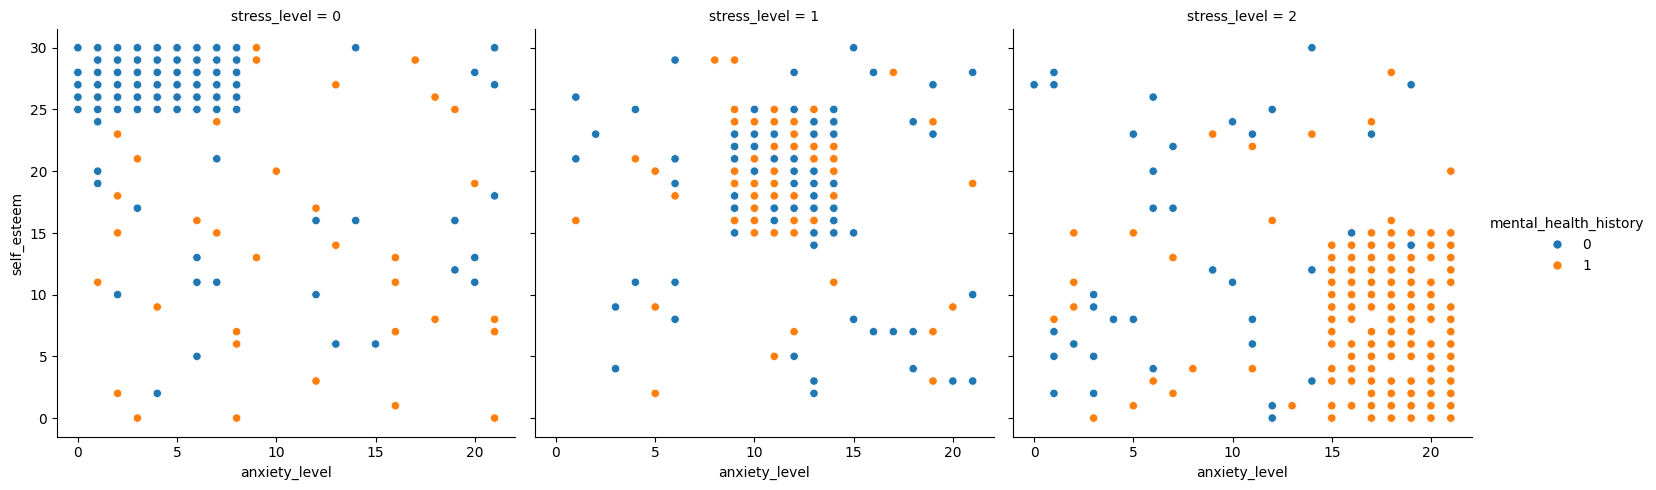

In [16]:
sns.relplot(data=df, x="anxiety_level", y="self_esteem", hue="mental_health_history", col="stress_level")

## this tells two things:
##1) lesser stess_level person has higher self-esteem and more stress level person has lower self-esteem and high anxiety.

<Axes: xlabel='mental_health_history', ylabel='depression'>

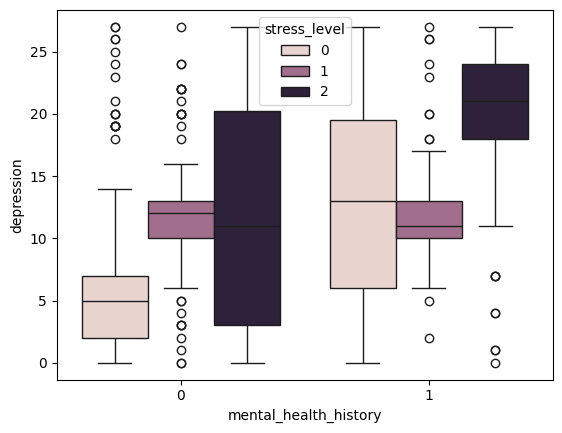

In [17]:
sns.boxplot(data=df, y="depression", x="mental_health_history", hue="stress_level")

Text(0.5, 1.0, 'Correlation Heatmap')

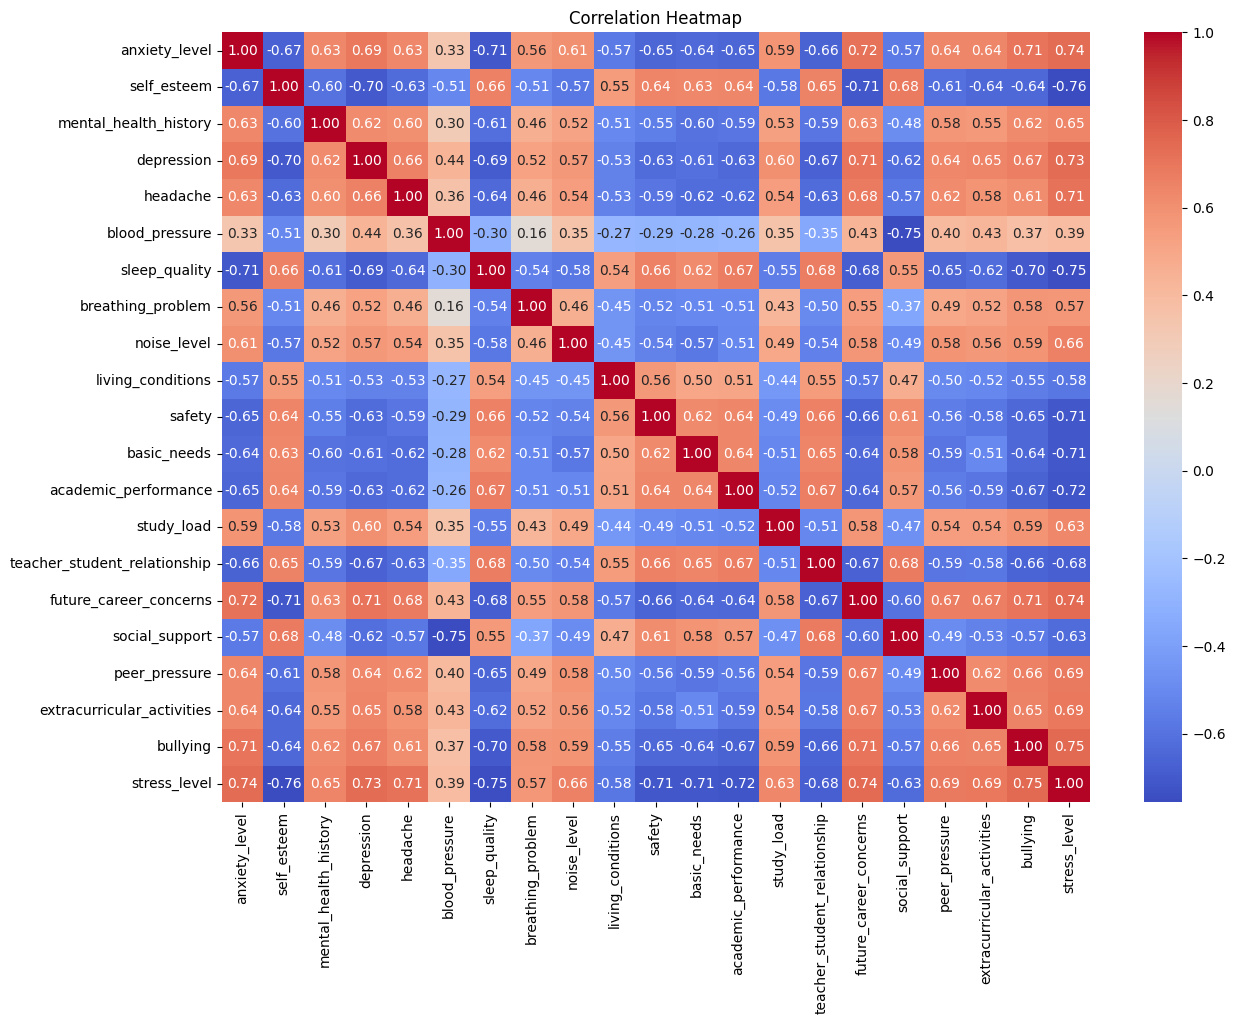

In [18]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')

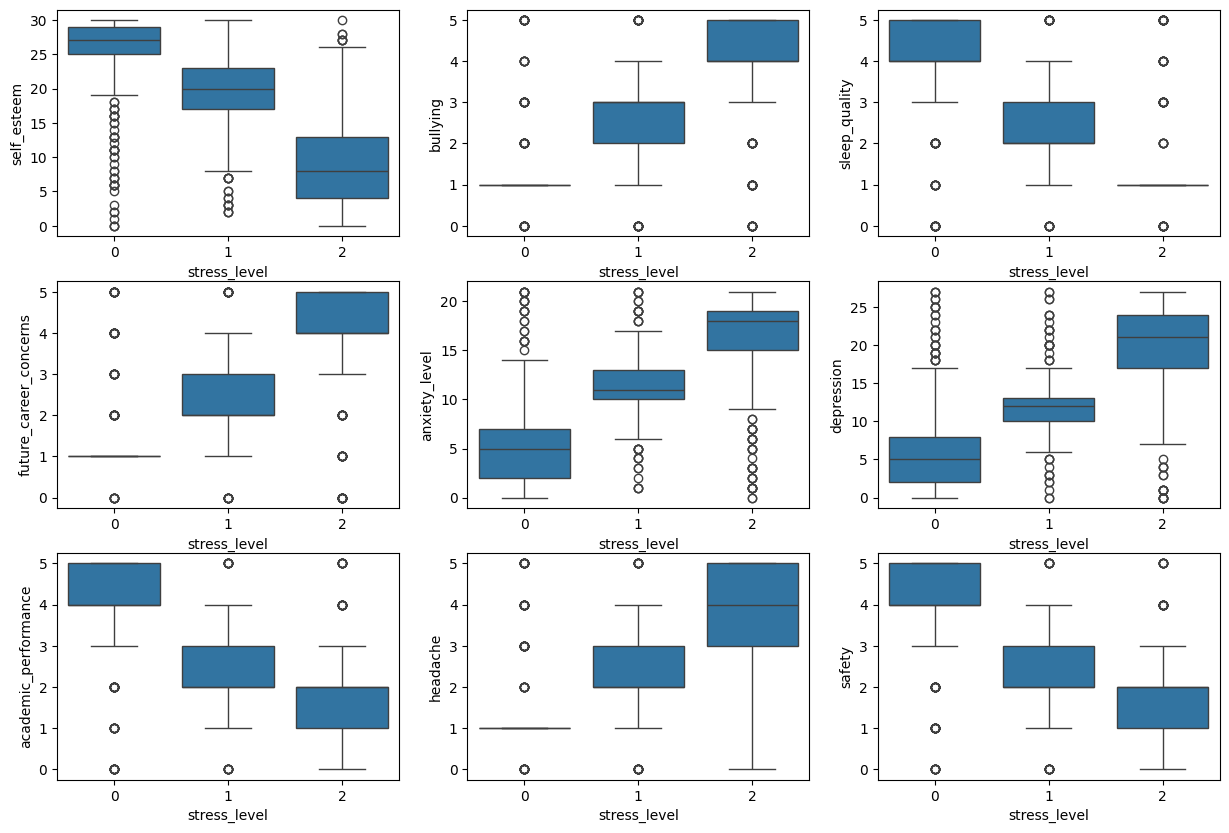

In [19]:
top_features = ["self_esteem",
                "bullying",
                "sleep_quality",                
                "future_career_concerns",          
                "anxiety_level",                   
                "depression",                      
                "academic_performance",            
                "headache",                        
                "safety"]

fig, axes = plt.subplots(3,3, figsize=(15,10))
axes = axes.flatten()

for i,col in enumerate(top_features):
    sns.boxplot(data=df ,x="stress_level", y=col,ax=axes[i])

## Model training

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop("stress_level", axis=1)
y = df["stress_level"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((880, 20), (220, 20))

In [21]:
y_train.value_counts, y_test.value_counts

(<bound method IndexOpsMixin.value_counts of 1069    1
 1091    2
 510     0
 844     2
 249     0
        ..
 13      2
 477     2
 3       2
 338     0
 1052    2
 Name: stress_level, Length: 880, dtype: int64>,
 <bound method IndexOpsMixin.value_counts of 150     0
 582     0
 450     2
 616     2
 1090    0
        ..
 1084    2
 554     0
 369     0
 176     2
 936     0
 Name: stress_level, Length: 220, dtype: int64>)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic regression model

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
y_pred_lr = lr.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

print("Accuracy of Logistic Regg.: ",accuracy_score(y_test, y_pred_lr))

Accuracy of Logistic Regg.:  0.8818181818181818


In [26]:
print("Confusion matrix of LR: ")
confusion_matrix(y_test, y_pred_lr)

Confusion matrix of LR: 


array([[63,  5,  6],
       [ 3, 66,  3],
       [ 7,  2, 65]])

In [27]:
print("Classification report of LR: ")
print(classification_report(y_test, y_pred_lr))

Classification report of LR: 
              precision    recall  f1-score   support

           0       0.86      0.85      0.86        74
           1       0.90      0.92      0.91        72
           2       0.88      0.88      0.88        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



In [28]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [29]:
y_pred_dt = dt.predict(X_test)

print("Accuracy of Decision tree.: ",accuracy_score(y_test, y_pred_dt))
## since accuracy of DT is less which means pattern is linear type

Accuracy of Decision tree.:  0.8545454545454545


In [30]:
print("Confusion matrix of DT: ")
confusion_matrix(y_test, y_pred_dt)

Confusion matrix of DT: 


array([[59,  8,  7],
       [ 6, 65,  1],
       [ 4,  6, 64]])

In [31]:
print("Classification report of DT: ")
print(classification_report(y_test, y_pred_dt))

Classification report of DT: 
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        74
           1       0.82      0.90      0.86        72
           2       0.89      0.86      0.88        74

    accuracy                           0.85       220
   macro avg       0.86      0.85      0.85       220
weighted avg       0.86      0.85      0.85       220



In [32]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=42)

rfc.fit(X_train, y_train)

y_pred_RFC = rfc.predict(X_test)

In [33]:
print("Accuracy of Random Forest is: ",accuracy_score(y_test, y_pred_RFC))

Accuracy of Random Forest is:  0.8909090909090909


### Tuning Hyperparameter for Random Forest

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy: 0.8818181818181818
TUNED RANDOM FOREST
Test Accuracy: 0.9090909090909091
              precision    recall  f1-score   support

         Low       0.90      0.89      0.90        74
      Medium       0.94      0.93      0.94        72
        High       0.88      0.91      0.89        74

    accuracy                           0.91       220
   macro avg       0.91      0.91      0.91       220
weighted avg       0.91      0.91      0.91       220



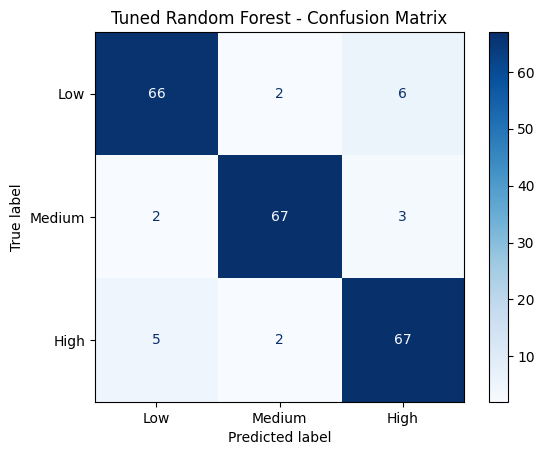

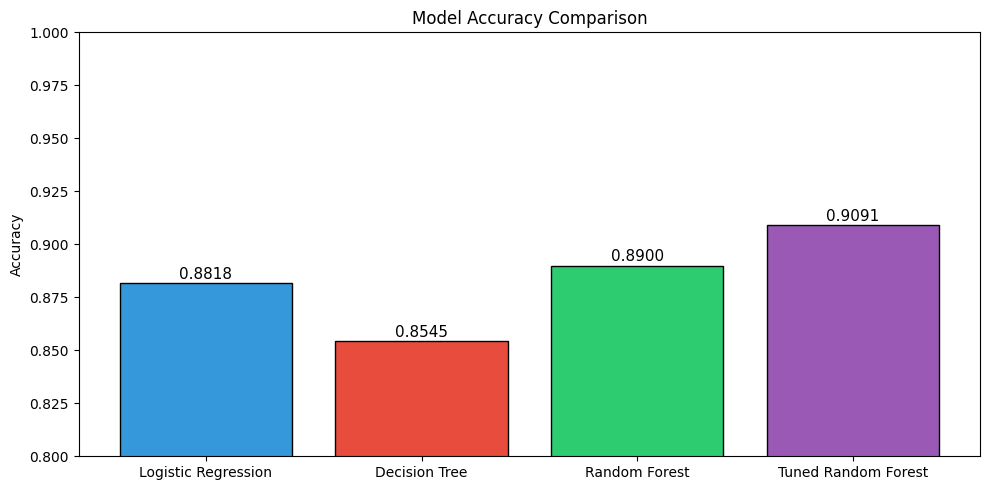

In [34]:
from sklearn.model_selection import GridSearchCV

#1. Define Parameter Grid 
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Grid Search 
rf_tuned = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,              # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,         # uses all CPU cores → faster
    verbose=1          # shows progress
)

rf_tuned.fit(X_train, y_train)

# 3. Best Parameters
print("Best Parameters:", rf_tuned.best_params_)
print("Best CV Accuracy:", rf_tuned.best_score_)

# ── 4. Evaluate Tuned Model ──────────────────────────────
y_pred_tuned = rf_tuned.best_estimator_.predict(X_test)

print("=" * 50)
print("TUNED RANDOM FOREST")
print("=" * 50)
print("Test Accuracy:", accuracy_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned,
      target_names=['Low','Medium','High']))

# ── 5. Confusion Matrix ──────────────────────────────────
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned,
                               display_labels=['Low','Medium','High'])
disp.plot(cmap='Blues')
plt.title('Tuned Random Forest - Confusion Matrix')
plt.show()

# ── 6. Updated Comparison Chart ──────────────────────────
models = ['Logistic Regression', 'Decision Tree',
          'Random Forest', 'Tuned Random Forest']
accuracies = [0.8818, 0.8545, 0.89,
              accuracy_score(y_test, y_pred_tuned)]

plt.figure(figsize=(10,5))
bars = plt.bar(models, accuracies,
               color=['#3498db','#e74c3c','#2ecc71','#9b59b6'],
               edgecolor='black')
plt.ylim(0.8, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

# 1. Save The Tuned Random Forest Model 
with open('stress_predictor_model.pkl', 'wb') as f:
    pickle.dump(rf_tuned.best_estimator_, f)

# 2. Save The Scaler Too
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as stress_predictor_model.pkl")
print("✅ Scaler saved as scaler.pkl")

# 3. Test Loading The Model Back
with open('stress_predictor_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print("\n✅ Model loaded successfully!")



✅ Model saved as stress_predictor_model.pkl
✅ Scaler saved as scaler.pkl

✅ Model loaded successfully!


In [36]:
# ── 4. Test Prediction With Loaded Model ─────────────────
sample_student = X_test.iloc[0:1]   # take one student from test set
prediction = loaded_model.predict(sample_student)
actual = y_test.iloc[0]

label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
print("\n── Sample Prediction Test ──")
print("Predicted Stress Level:", label_map[prediction[0]])
print("Actual Stress Level:   ", label_map[actual])

# ── 5. Predict On Multiple Students ─────────────────────
sample_5 = X_test.iloc[0:5]
predictions_5 = loaded_model.predict(sample_5)
actuals_5 = y_test.iloc[0:5].values

print("\n── 5 Student Predictions ──")
results = pd.DataFrame({
    'Actual': [label_map[a] for a in actuals_5],
    'Predicted': [label_map[p] for p in predictions_5],
    'Correct': ['✅' if a == p else '❌' 
                for a, p in zip(actuals_5, predictions_5)]
})
print(results)


── Sample Prediction Test ──
Predicted Stress Level: Low
Actual Stress Level:    Low

── 5 Student Predictions ──
  Actual Predicted Correct
0    Low       Low       ✅
1    Low       Low       ✅
2   High      High       ✅
3   High      High       ✅
4    Low      High       ❌
